| 항목                      | 정상 하한 | 경계 상한 (risk\_max) | 방향        | 비고              |
| ----------------------- | ----------- | -------------- | --------- | --------------- |
| 혈색소 (Hemoglobin)        |  11 | 18 | ↑ 낮을수록 위험 | 성별 구분 필요할 수도 있음 |
| 트리글리세라이드 (Triglyceride) | 50 | 200 | ↑ 높을수록 위험 | 공복 시 수치 기준      |
| HDL 콜레스테롤 (HDL)         | 45 | 100 | ↓ 낮을수록 위험 | 낮을수록 고위험군       |
| 감마지티피 (Gamma-GTP)       |  10 | 70 | ↑ 높을수록 위험 | 간 기능 지표         |
| 식전혈당 (Fasting Glucose)  |  70 | 125  | ↑ 높을수록 위험 | 126 이상 당뇨 의심    |

In [83]:
NORMALIZATION_RULES = {
    '혈색소':                 {'min': 11,  'risk_max': 18,  'direction': 'low'},
    '트리글리세라이드':         {'min': 50,  'risk_max': 200, 'direction': 'high'},
    'HDL콜레스테롤':           {'min': 45,  'risk_max': 100, 'direction': 'low'},
    '감마지티피':              {'min': 10,  'risk_max': 70,  'direction': 'high'},
    '식전혈당(공복혈당)':       {'min': 70,  'risk_max': 125, 'direction': 'high'}
}

In [144]:
NORMALIZATION_RULES = {
    '혈색소':                 {'min': 11,  'risk_max': 18,  'direction': 'low'},
    '트리글리세라이드':         {'min': 50,  'risk_max': 200, 'direction': 'high'},
    'HDL콜레스테롤':           {'min': 45,  'risk_max': 100, 'direction': 'low'},
    '감마지티피':              {'min': 10,  'risk_max': 70,  'direction': 'high'},
    '식전혈당(공복혈당)':       {'min': 70,  'risk_max': 125, 'direction': 'high'},
    '연령대코드(5세단위)':      {'min': 4,  'risk_max': 16,  'direction': 'high'},
    'bmi':                    {'min': 18,  'risk_max': 23, 'direction': 'high'}
}

In [84]:
user_values = {
    '혈색소': 13.2,
    '트리글리세라이드': 180,
    'HDL콜레스테롤': 38,
    '감마지티피': 65,
    '식전혈당(공복혈당)': 115
}

In [145]:
def normalize_health_inputs(user_values, normalization_rules):
    """
    사용자 전체 건강 수치를 일괄 정규화하는 함수
    user_values: {'항목명': 수치, ...}
    normalization_rules: {'항목명': {'min': x, 'risk_max': y, 'direction': z}, ...}
    
    return: {'항목명': 정규화 점수}
    """
    normalized_scores = {}

    for key, value in user_values.items():
        if key in normalization_rules:
            rule = normalization_rules[key]
            min_val = rule['min']
            risk_max = rule['risk_max']
            direction = rule['direction']
            
            try:
                norm = (value - min_val) / (risk_max - min_val)
                if direction == 'low':
                    norm = 1 - norm
                norm = max(0, min(1, norm))
                normalized_scores[key] = round(norm, 4)
            except ZeroDivisionError:
                normalized_scores[key] = 0.0  # 예외 처리
        else:
            normalized_scores[key] = None  # 기준이 없는 경우

    return normalized_scores

In [86]:
normalized = normalize_health_inputs(user_values, NORMALIZATION_RULES)

# 결과 예시 출력
for k, v in normalized.items():
    print(f"{k}: 정규화 {v}")

혈색소: 정규화 0.6857
트리글리세라이드: 정규화 0.8667
HDL콜레스테롤: 정규화 1
감마지티피: 정규화 0.9167
식전혈당(공복혈당): 정규화 0.8182


In [146]:
COEFFICIENTS = {
    '혈색소': 0.11,
    '트리글리세라이드': 0.09,
    'HDL콜레스테롤': 0.08,
    '감마지티피': 0.06,
    '식전혈당(공복혈당)': 0.05,
    '연령대코드(5세단위)': 0.48,
    'bmi': 0.23
}

In [147]:
def calculate_risk_score(normalized_scores, coefficients):
    """
    정규화된 수치와 회귀 계수를 곱해 최종 위험도 점수 계산
    """
    score = 0.0
    for key, norm_value in normalized_scores.items():
        coef = coefficients.get(key, 0)
        score += norm_value * coef
    return round(score, 4)

In [148]:
final_risk_score = calculate_risk_score(normalized, COEFFICIENTS)

# 5. 출력
print("정규화된 점수:", normalized)
print("최종 위험 점수:", final_risk_score)

정규화된 점수: {'혈색소': 0.6857, '트리글리세라이드': 0.8667, 'HDL콜레스테롤': 1, '감마지티피': 0.9167, '식전혈당(공복혈당)': 0.8182}
최종 위험 점수: 0.3293


In [149]:
import pandas as pd

df = pd.read_csv("../data/processed/health_checkup_vision_processed.csv")

In [150]:
features = [
    '식전혈당(공복혈당)',
    '혈색소',
    '감마지티피',
    '트리글리세라이드',
    'HDL콜레스테롤',
    '연령대코드(5세단위)',
    'bmi'
]

In [151]:
df_risk_score = df[features]

In [152]:
df_risk_score['risk_score'] = df_risk_score.apply(
    lambda row: calculate_risk_score(
        normalize_health_inputs(row.to_dict(), NORMALIZATION_RULES),
        COEFFICIENTS
    ), axis=1
)

C:\Users\asia\AppData\Local\Temp\ipykernel_29500\302570797.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_risk_score['risk_score'] = df_risk_score.apply(


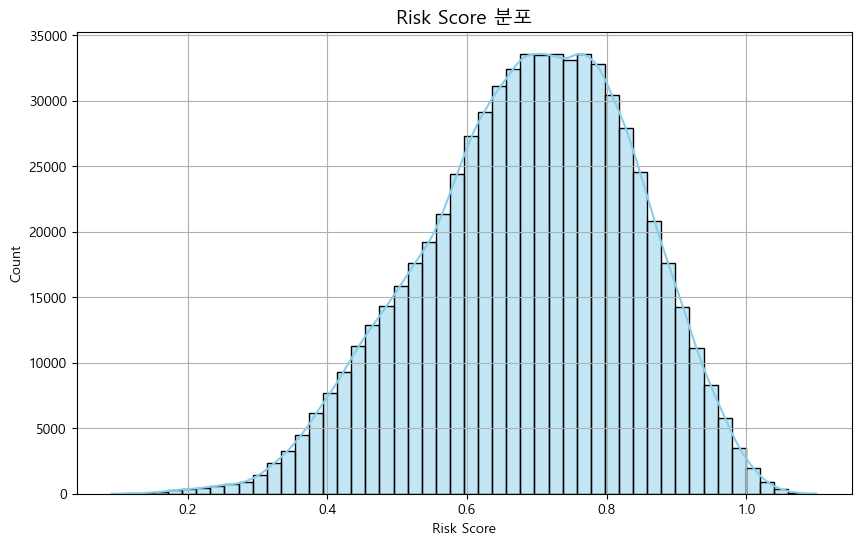

In [153]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_risk_score['risk_score'], bins=50, kde=True, color='skyblue')
plt.title("Risk Score 분포", fontsize=14)
plt.xlabel("Risk Score")
plt.ylabel("Count")
plt.grid(True)
plt.show()

In [154]:
df_risk_score['risk_score'].describe()

count    662623.000000
mean          0.687934
std           0.149896
min           0.091500
25%           0.588200
50%           0.698300
75%           0.798600
max           1.100000
Name: risk_score, dtype: float64

In [155]:
def classify_risk(score):
    if score <= 0.4:
        return '양호'
    elif score <= 0.65:
        return '주의'
    elif score <= 0.85:
        return '위험'
    else:
        return '고위험'

df_risk_score['risk_level'] = df_risk_score['risk_score'].apply(classify_risk)

C:\Users\asia\AppData\Local\Temp\ipykernel_29500\458893538.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_risk_score['risk_level'] = df_risk_score['risk_score'].apply(classify_risk)


In [156]:
df['risk_score'] = df_risk_score['risk_score']
df['risk_level'] = df_risk_score['risk_level']

C:\Users\asia\AppData\Local\Temp\ipykernel_29500\1846962519.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='risk_level', y='수축기혈압', order=['양호', '주의', '위험', '고위험'], palette='Set2')


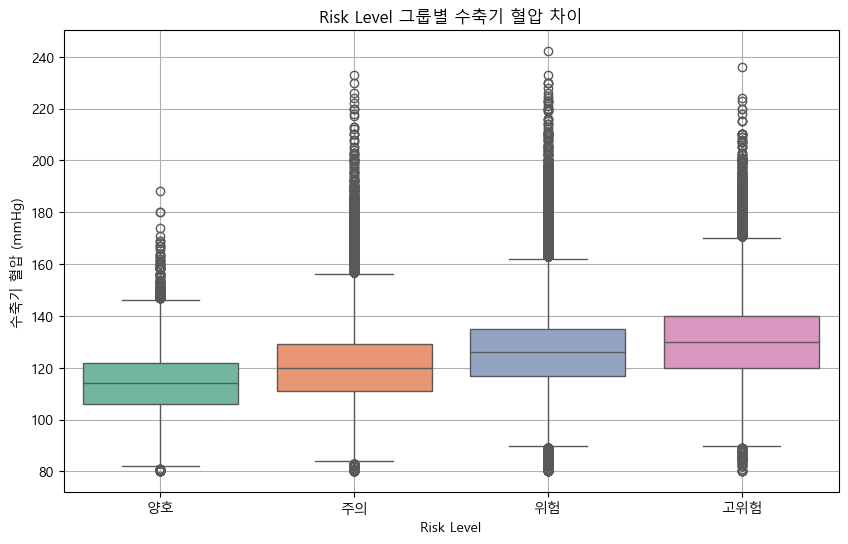

In [158]:
plt.rcParams['font.family'] = 'Malgun Gothic'   # 윈도우: 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False      # 마이너스 기호 깨짐 방지

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='risk_level', y='수축기혈압', order=['양호', '주의', '위험', '고위험'], palette='Set2')
plt.title("Risk Level 그룹별 수축기 혈압 차이")
plt.ylabel("수축기 혈압 (mmHg)")
plt.xlabel("Risk Level")
plt.grid(True)
plt.show()

C:\Users\asia\AppData\Local\Temp\ipykernel_29500\374686878.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='risk_level', y='pulse_pressure', order=['정상', '주의', '위험', '고위험'], palette='Set2')


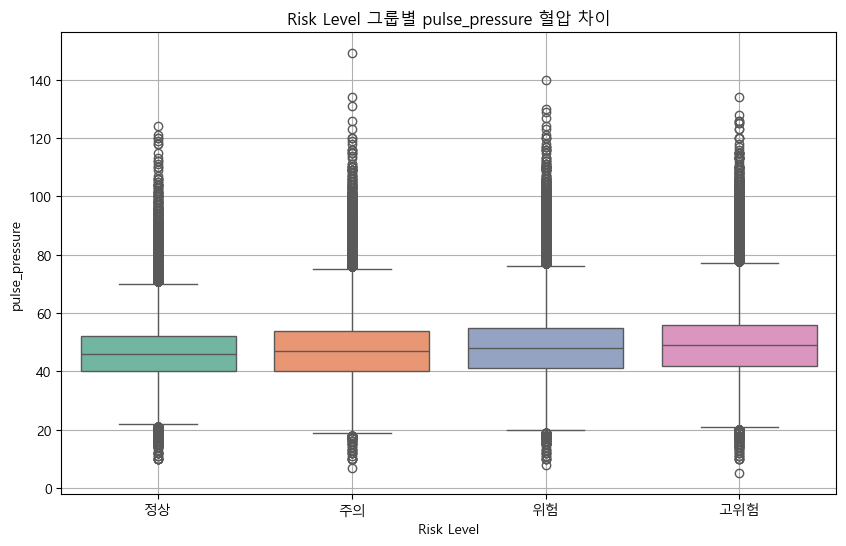

In [112]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='risk_level', y='pulse_pressure', order=['정상', '주의', '위험', '고위험'], palette='Set2')
plt.title("Risk Level 그룹별 pulse_pressure 혈압 차이")
plt.ylabel("pulse_pressure")
plt.xlabel("Risk Level")
plt.grid(True)
plt.show()

In [162]:
from scipy.stats import f_oneway

groups = [df[df['risk_level'] == g]['수축기혈압'].dropna() for g in ['양호', '주의', '위험', '고위험']]
f_stat, p_val = f_oneway(*groups)

print(f"ANOVA F={f_stat:.4f}, p={p_val:.4g}")

ANOVA F=21607.6452, p=0


In [159]:
df.groupby('risk_level')[['수축기혈압', '이완기혈압']].mean().round(2)

,수축기혈압,이완기혈압
risk_level,,
고위험,131.78,75.93
양호,114.51,70.84
위험,126.21,77.54
주의,120.14,74.76


In [160]:
df[df['risk_level'] == '양호'].describe()

,성별코드,연령대코드(5세단위),신장(5cm단위),체중(5kg단위),허리둘레,수축기혈압,이완기혈압,식전혈당(공복혈당),총콜레스테롤,트리글리세라이드,...,음주여부,bmi,alt_ast_ratio,tg_hdl_ratio,ggtp_alt_ratio,ldl_hdl_ratio,pulse_pressure,hypertension_status,시력(평균),risk_score
count,23340.000000,23340.000000,23340.000000,23340.000000,23340.000000,23340.000000,23340.000000,23340.000000,23340.000000,23340.000000,...,23340.000000,23340.000000,23340.000000,23340.000000,23340.000000,23340.000000,23340.000000,23340.000000,23340.000000,23340.000000
mean,1.417481,7.519923,166.486290,53.720223,69.974494,114.512382,70.837618,88.976907,190.801628,69.587078,...,0.749272,19.247789,0.796281,1.067768,1.214824,1.594576,43.674764,0.027849,1.032367,0.343035
std,0.493154,1.814030,8.474627,9.719541,6.927680,11.754132,9.036070,10.132268,33.731148,28.789585,...,0.433442,2.230431,0.285624,0.603938,0.757392,0.557917,8.553585,0.164544,0.411621,0.053052
min,1.000000,5.000000,130.000000,30.000000,48.000000,80.000000,40.000000,50.000000,100.000000,20.000000,...,0.000000,11.019284,0.045455,0.170940,0.059633,0.139130,10.000000,0.000000,0.100000,0.091500
25%,1.000000,6.000000,160.000000,45.000000,65.000000,106.000000,64.000000,83.000000,167.000000,50.000000,...,0.000000,17.578125,0.625000,0.681818,0.800000,1.205479,38.000000,0.000000,0.850000,0.321700
50%,1.000000,8.000000,165.000000,50.000000,70.000000,114.000000,70.000000,89.000000,188.000000,64.000000,...,1.000000,18.730489,0.750000,0.925000,1.076923,1.517857,43.000000,0.000000,1.000000,0.359100
75%,2.000000,9.000000,175.000000,60.000000,74.900000,122.000000,77.000000,95.000000,211.000000,82.000000,...,1.000000,20.761246,0.919189,1.272727,1.437500,1.897959,49.000000,0.000000,1.200000,0.382500
max,2.000000,13.000000,195.000000,120.000000,119.000000,188.000000,131.000000,282.000000,386.000000,368.000000,...,1.000000,40.404040,12.920000,10.000000,27.800000,7.071429,91.000000,1.000000,9.900000,0.400000


<Axes: xlabel='risk_level', ylabel='수축기혈압'>

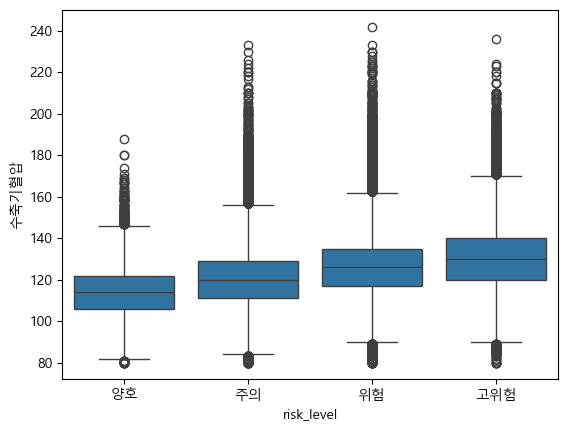

In [165]:
sns.boxplot(data=df, x='risk_level', y='수축기혈압', order=['양호', '주의', '위험', '고위험'])

In [196]:
def calculate_bmr_mifflin(sex: str, age: int, height_cm: float, weight_kg: float) -> float:
    """
    BMR 계산 (Mifflin–St Jeor 공식 기준, 최신 표준)
    - sex: '남성' 또는 '여성'
    - age: 나이 (년)
    - height_cm: 키 (cm)
    - weight_kg: 몸무게 (kg)
    - 반환값: 하루 기초대사량 (kcal), 소수점 1자리
    """
    sex = sex.lower()
    
    if sex == '남성':
        bmr = 10 * weight_kg + 6.25 * height_cm - 5 * age + 5
    elif sex == '여성':
        bmr = 10 * weight_kg + 6.25 * height_cm - 5 * age - 161
    else:
        raise ValueError("성별은 '남성' 또는 '여성'이어야 합니다.")
    
    return round(bmr, 1)

## BMR (기초대사량)이란?

- **기초대사량(Basal Metabolic Rate, BMR)**은 **휴식 상태에서 신체가 생명을 유지하는 데 필요한 최소한의 에너지**를 의미
- BMR은 **개인 맞춤 식이요법** 및 **1일 영양 섭취 목표 설정의 기준**으로 활용

---

## BMR 쓴 이유

1. **개인의 에너지 요구량을 반영하여**
2. **1일 영양소 기준치를 사용자에 맞게 조정하고**
3. **식품 성분을 정량적으로 평가**하기 위해 사용

---

## BMR 계산 공식 (Mifflin–St Jeor, 1990)

> 현재 병원, 임상영양, 운동처방 등에서 가장 널리 쓰이는 공식

- **남성**:  
  `BMR = 10 × 체중(kg) + 6.25 × 키(cm) − 5 × 나이 + 5`

- **여성**:  
  `BMR = 10 × 체중(kg) + 6.25 × 키(cm) − 5 × 나이 − 161`

---

## 출처

> Mifflin MD, St Jeor ST, et al.  
> *A new predictive equation for resting energy expenditure in healthy individuals.*  
> *The American Journal of Clinical Nutrition, 1990.*  
> [https://doi.org/10.1093/ajcn/51.2.241](https://doi.org/10.1093/ajcn/51.2.241)

---

## 예시

- 32세 여성, 162cm, 58kg  
→ `BMR ≈ 1282.5 kcal/day`

---

## CareBite에서의 활용

- BMR은 DASH 식단 기준(2100kcal 등)을 **사용자 맞춤형 1일 기준치로 환산**할 때 사용


In [172]:
def compute_metabolic_score(bmr: float, bmi: float) -> float:
    """
    BMR과 BMI를 기반으로 0~1 사이의 metabolic_score를 계산.
    값이 1에 가까울수록 대사 건강 상태가 좋음을 의미함.
    
    - BMR 정규화 기준: 1200~2500 kcal
    - BMI 정규화 기준: 중심 22, ±10 범위
    - 가중치: BMR(40%), BMI(60%)
    """
    # BMR 정규화 (1200~2500 kcal 기준)
    normalized_bmr = (bmr - 1200) / (2500 - 1200)
    normalized_bmr = max(0, min(1, normalized_bmr))  # 안정성 확보
    
    # BMI 점수화 (22 중심, 거리 기반 감점)
    bmi_distance = abs(bmi - 22)
    normalized_bmi_score = max(0, 1 - (bmi_distance / 10))

    # 가중 평균 계산
    metabolic_score = (normalized_bmr * 0.4) + (normalized_bmi_score * 0.6)
    
    return round(metabolic_score, 3)


### Q. BMR 0.4 / BMI 0.6 가중치는 어떤 기준으로 정한 건가요?

우리는 `metabolic_score`를 통해 개인의 대사 건강 상태를 수치화하는 과정에서 다음 기준을 적용

---

#### 1. 의료적 중요도 기반 가중치 설정

- **BMI**는 각종 질병(고혈압, 당뇨, 심혈관 질환 등)과의 직접적인 상관관계가 높고,
  - 22~23 사이에서 가장 낮은 사망률을 보이는 것으로 알려져 있어,
  - 이를 중심으로 한 **건강위험 예측 지표로서의 비중을 높게 반영**

- **BMR**은 기초적인 대사능력과 에너지 소비 패턴을 나타내며,
  - 체내 에너지 요구량을 기준으로 개인화된 권장 섭취량을 도출하는 데 활용

→ 따라서, **현재 건강 위험도에 더 민감하게 반응하는 BMI에 60%,  
에너지 소비 능력을 보조적으로 반영하는 BMR에 40%의 가중치를 적용**

---

#### 참고

- BMI는 WHO와 다수 역학연구에서 **질병 및 사망률과의 강한 상관관계**가 입증됨
- BMR은 **에너지 요구량 기준** 설정과 **활력 상태 평가**에 유효한 지표로 활용

---

#### 한 줄 요약

> "현재 건강 위험도에 더 직접적으로 영향을 주는 BMI에 더 높은 가중치를 주었고,  
> BMR은 보조적 대사 능력 지표로서 보완적인 역할을 반영

In [173]:
def compute_health_index(risk_score: float, metabolic_score: float, a: float = 0.7) -> float:
    """
    risk_score와 metabolic_score를 기반으로 health_index 계산
    - risk_score: 0~1 범위 (예측된 고혈압 위험도)
    - metabolic_score: 0~1 범위
    - a: 위험도에 부여할 가중치 (기본값 0.7)
    - 반환값: 0~1 범위의 health_index (높을수록 성분에 민감)
    """
    
    health_index = (risk_score * a) + ((1 - metabolic_score) * (1 - a))
    return round(health_index, 3)

- 고혈압 등 **질병 위험 예측**에 기반한 식품 추천
- 동시에, **개인의 대사 건강 상태(BMR, BMI)**도 보조적으로 고려

---

#### `a = 0.7` 선택 이유

- **질병 위험도 중심의 식품 추천 설계**를 반영
- 전체 건강 민감도 평가에 있어  
  → `risk_score` 70%  
  → `metabolic_score` 30%의 비중으로 구성
- 위험이 높은 사용자는 동일 성분에 더 민감하게 반응하도록 설계됨

---

> "CareBite는 위험 질환 예측을 핵심 판단 기준으로 삼고,  
> 대사 건강(BMR/BMI)은 보조 요인으로 반영합니다.  
> 따라서 `a = 0.7`로 설정해 두 요소 간의 균형을 잡았습니다."

In [211]:
b_values = {
    '나트륨(mg)': 0.31,
    '지방(g)': 0.20,
    '단백질(g)': 0.20,
    '탄수화물(g)': 0.15,
    '포화지방산(g)': 0.05,
    '콜레스테롤(mg)': 0.05,
    '칼륨(mg)': 0.02,
    '칼슘(mg)': 0.01,
    '식이섬유(g)': 0.01    
}

In [212]:
def adjust_dash_standard(bmr: float) -> dict:
    """
    사용자의 BMR에 따라 DASH 기준을 개인화해서 반환.
    """
    scale = bmr / 2100  # 2100kcal 기준에서 비례 조정

    return {
        '나트륨(mg)': 2300,
        '지방(g)': bmr * 0.27,
        '단백질(g)': bmr * 0.18,
        '탄수화물(g)': bmr * 0.55,
        '포화지방산(g)': bmr * 0.06,
        '콜레스테롤(mg)': 150,
        '칼륨(mg)': 4700,
        '칼슘(mg)': 1250,
        '식이섬유(g)': 30
    }

In [261]:
def compute_weight_per_nutrient(health_index: float, b_values: dict) -> dict:
    """
    health_index와 성분별 b값을 곱하여 가중치 계산
    """
    return {
        nutrient: round((health_index ** 2) * b, 4)
        for nutrient, b in b_values.items()
    }

In [176]:
def compute_deviation_ratio(value, standard, tolerance=0.1):
    """
    기준에서 얼마나 벗어났는지를 비율로 계산.
    허용 오차(tolerance)를 넘을 때만 감점.
    """
    lower_bound = standard * (1 - tolerance)
    upper_bound = standard * (1 + tolerance)

    if lower_bound <= value <= upper_bound:
        return 0  # 허용 범위 이내면 감점 없음
    else:
        return abs(value - standard) / standard  # 기준 대비 벗어난 비율

In [301]:
def calculate_health_score(food, dash_standard, nutrient_weights, nutrients, tolerance=0.1):
    base_score = 100
    total_penalty = 0

    for nutrient in nutrients:
        value = food[nutrient]
        standard = dash_standard[nutrient]
        weight = nutrient_weights[nutrient]

        deviation_ratio = compute_deviation_ratio(value, standard, tolerance)
        penalty = (np.exp(deviation_ratio) - 1) * weight  # 로그 기반 패널티 적용

        total_penalty += penalty

    # 감점 후 점수 계산 (최소 0점으로 제한, 100점 만점)
    health_score = max(0, base_score - (total_penalty * 100))
    return round(health_score, 2)

In [223]:
df = pd.read_csv("../data/raw/combined_filterd_fd.csv")

C:\Users\asia\AppData\Local\Temp\ipykernel_29500\1050980831.py:1: DtypeWarning: Columns (44,46,48,50,52,54,56,167) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/combined_filterd_fd.csv")


In [179]:
df.columns

Index(['식품코드', '식품명', '데이터구분코드', '데이터구분명', '에너지(kcal)', '영양성분함량기준량', '수분(g)',
       '단백질(g)', '지방(g)', '회분(g)',
       ...
       '타우린(mg)', '트레오닌(mg)', '트립토판(mg)', '티로신(mg)', '페닐알라닌(mg)', '프롤린(mg)',
       '히스티딘(mg)', '토코페롤(mg)', '토코트리에놀(mg)', '1회 섭취참고량'],
      dtype='object', length=168)

In [200]:
food_features = [
    '나트륨(mg)',
    '지방(g)',
    '단백질(g)',
    '탄수화물(g)',
    '포화지방산(g)',
    '콜레스테롤(mg)',
    '칼륨(mg)',
    '칼슘(mg)',
    '식이섬유(g)'
]

In [183]:
food = df[food_features]

In [184]:
food.head()

,나트륨(mg),지방(g),단백질(g),탄수화물(g),포화지방산(g),콜레스테롤(mg),칼륨(mg),칼슘(mg),식이섬유(g)
0,280.0,3.20,7.60,22.80,0.52,20.00,0.0,0.0,0.0
1,284.0,3.20,10.40,18.40,0.84,14.00,0.0,0.0,0.0
2,252.0,4.40,8.40,20.40,0.76,20.00,0.0,0.0,0.0
3,140.0,2.31,9.62,22.31,0.38,13.85,0.0,0.0,0.0
4,324.0,3.24,9.80,25.40,0.60,14.00,0.0,0.0,0.0


In [ ]:
user_input_1 = {
    '나이': 25,
    '성별': '남성',
    '키': 178,
    '체중': 70,
    '혈색소': 15.5,
    '트리글리세라이드': 80,
    'HDL콜레스테롤': 65,
    '감마지티피': 20,
    '식전혈당(공복혈당)': 85
}
# 고령 + 고위험 상태
user_input_2 = {
    '나이': 75,
    '성별': '여성',
    '키': 150,
    '체중': 80,
    '혈색소': 10.5,
    '트리글리세라이드': 250,
    'HDL콜레스테롤': 30,
    '감마지티피': 95,
    '식전혈당(공복혈당)': 135
}
# 젋지만 대사 상태 나쁨
user_input_3 = {
    '나이': 28,
    '성별': '남성',
    '키': 175,
    '체중': 100,
    '혈색소': 14.5,
    '트리글리세라이드': 220,
    'HDL콜레스테롤': 33,
    '감마지티피': 90,
    '식전혈당(공복혈당)': 120
}
# 고령 저체중 + 당뇨지표
user_input_4 = {
    '나이': 68,
    '성별': '여성',
    '키': 158,
    '체중': 45,
    '혈색소': 11.0,
    '트리글리세라이드': 190,
    'HDL콜레스테롤': 40,
    '감마지티피': 60,
    '식전혈당(공복혈당)': 140
}

In [247]:
user_checkup= [
    '혈색소', 
    '트리글리세라이드',
    'HDL콜레스테롤',
    '감마지티피',
    '식전혈당(공복혈당)'
]

In [305]:
BMI_1 = user_input_1['체중'] / ((user_input_1['키'] / 100) ** 2)

In [296]:
BMI_2 = user_input_2['체중'] / ((user_input_2['키'] / 100) ** 2)

In [297]:
BMI_3 = user_input_3['체중'] / ((user_input_3['키'] / 100) ** 2)

In [271]:
normalized_values = {key: normalized[key] for key in user_checkup}

In [272]:
normalized_values

{'혈색소': 0.6857, '트리글리세라이드': 1, 'HDL콜레스테롤': 1, '감마지티피': 0.9167, '식전혈당(공복혈당)': 1}

In [312]:
normalized = normalize_health_inputs(user_input_2, NORMALIZATION_RULES)
risk_score = calculate_risk_score(normalized_values, COEFFICIENTS)

bmr = calculate_bmr_mifflin(user_input_2['성별'], user_input_2['나이'], user_input_2['키'], user_input_2['체중'])
metabolic_score = compute_metabolic_score(bmr, BMI_2)

health_index = compute_health_index(risk_score, metabolic_score)

In [ ]:
normalized = normalize_health_inputs(user_input_3, NORMALIZATION_RULES)
risk_score = calculate_risk_score(normalized_values, COEFFICIENTS)

bmr = calculate_bmr_mifflin(user_input_3['성별'], user_input_3['나이'], user_input_3['키'], user_input_3['체중'])
metabolic_score = compute_metabolic_score(bmr, BMI)

health_index = compute_health_index(risk_score, metabolic_score)

In [306]:
normalized = normalize_health_inputs(user_input_1, NORMALIZATION_RULES)
risk_score = calculate_risk_score(normalized_values, COEFFICIENTS)

bmr = calculate_bmr_mifflin(user_input_1['성별'], user_input_1['나이'], user_input_1['키'], user_input_1['체중'])
metabolic_score = compute_metabolic_score(bmr, BMI_1)

health_index = compute_health_index(risk_score, metabolic_score)

In [307]:
health_index

0.321

In [313]:
import numpy as np

user_dash_standard = adjust_dash_standard(bmr)
user_weights = compute_weight_per_nutrient(health_index, b_values)

scores = []

for _, food in df.iterrows():
    score = calculate_health_score(food, user_dash_standard, user_weights, food_features)
    scores.append(score)

df['health_score'] = scores

In [318]:
df[['식품명', 'health_score']].sort_values(by='health_score', ascending=False).head(50)

,식품명,health_score
118787,일품 무조미곱창김,77.78
24594,우삼겹 유부초밥,77.41
19356,모오롱 삼겹살 김치찌개,75.32
118732,목포는항구다 아몬드 김스낵,74.95
109381,마포 조박집 양념구이,74.19
61559,비건 쌀 밤식빵 생지,73.86
119151,다원 두번 구운 김밥용김,73.85
24584,치킨 유부초밥,73.52
3624,몽콕식튀김만두,73.27
119469,반다란 올리브유 김자반,73.21


In [293]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121776 entries, 0 to 121775
Columns: 169 entries, 식품코드 to health_score
dtypes: float64(142), int64(4), object(23)
memory usage: 157.0+ MB


In [283]:
df['health_score'].value_counts()

health_score
84.38    3233
84.39    3123
84.40    2121
84.37    2060
84.52    1717
         ... 
80.66       1
80.38       1
89.48       1
82.16       1
90.10       1
Name: count, Length: 663, dtype: int64